# Phase 5R Predictive Information and Conditional Combination Modeling

This executed notebook reads Phase 5R result artifacts only. It does not open the Phase 4 target matrix or any locked-test target row.

## 1. Phase 5R Objective and Research Question

**Analytical question:** Does history assign useful probability to a complete next draw? Proper scoring of complete outcomes answers this directly.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** Read the evidence summary and state the result without converting marginal frequency into a prediction claim.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
EVIDENCE = json.loads((ROOT / 'reports/phase5r_evidence.json').read_text(encoding='utf-8'))
INFO = pd.read_csv(ROOT / 'reports/phase5r_information_tests.csv')
PERM = pd.read_csv(ROOT / 'reports/phase5r_information_permutations.csv')
TEMP = pd.read_csv(ROOT / 'reports/phase5r_temporal_dependence.csv')
STATION = pd.read_csv(ROOT / 'reports/phase5r_stationarity.csv')
BAYES = pd.read_csv(ROOT / 'reports/phase5r_bayesian_shrinkage.csv')
METRICS = pd.read_csv(ROOT / 'reports/phase5r_combination_probability_metrics.csv')

print(EVIDENCE['research_question'])
print('Verdict:', EVIDENCE['verdict'])

Given only information available before draw t, does the historical record contain enough information to assign a next-draw combination probability distribution that performs better than the appropriate fair-random baseline on chronological validation data?
Verdict: PHASE5R_INCONCLUSIVE


## 2. Existing Evidence from Phases 1 through 5A

**Analytical question:** Prior phase verdicts and saved audits establish the approved starting point.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** Phase 5A validation was already examined, so this remains development evidence.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

In [2]:
display(pd.DataFrame([{'phase': '3', 'verdict': EVIDENCE['preflight']['phase3_verdict']}, {'phase': '4', 'verdict': EVIDENCE['preflight']['phase4_verdict']}, {'phase': '5A', 'verdict': EVIDENCE['preflight']['phase5a_verdict']}]))

,phase,verdict
0,3,PHASE3_PASS_RANDOM_COMPATIBLE
1,4,PHASE4_PASS_READY_FOR_ML_BASELINE
2,5A,PHASE5A_INCONCLUSIVE


## 3. Data and Chronological Boundary Verification

**Analytical question:** Checking the recorded split metadata and parsed row counts makes the test boundary auditable.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** Locked test data appears as metadata only; no test target rows are loaded.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

In [3]:
display(pd.DataFrame([{'game': game, **parts['test']} for game, parts in EVIDENCE['data_boundaries'].items()]))
print('Rows parsed:', {game: item['dev_rows_parsed'] for game, item in EVIDENCE['data_read_audit'].items()})

,game,end_date,row_count,start_date
0,3d_lotto,2026-10-07,724,2024-10-08
1,lotto_6_42,2026-10-06,302,2024-10-24


Rows parsed: {'3d_lotto': 2893, 'lotto_6_42': 1202}


## 4. Fair-Random Combination Models

**Analytical question:** The null must match each game's outcome space, including 3D multiplicity and fixed six-number cardinality.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** The fair 3D outcome probabilities differ by multiplicity class; 6/42 sets share one fair probability.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

In [4]:
display(pd.DataFrame([{'game': '3d_lotto', **EVIDENCE['fair_random_verification']['3d']}, {'game': 'lotto_6_42', **EVIDENCE['fair_random_verification']['642']}]))

,game,all_distinct_probability_each,fair_model_computed_from_multinomial_coefficients,fair_probability_sum,multiset_count,one_pair_probability_each,ordered_outcomes,triple_probability_each,exact_normalizer_method,fair_normalizer,fair_probability_each,synthetic_dp_normalizer,synthetic_enumerated_normalizer,valid_set_count,weighted_model_support
0,3d_lotto,0.006,True,1.0,220.0,0.003,1000.0,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lotto_6_42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sixth elementary symmetric polynomial computed...,5245786.0,1.906292e-07,27.06875,27.06875,5245786.0,all six-element subsets of 42 positive-weight ...


## 5. Information-Theoretic Framework

**Analytical question:** Candidate-level mutual information estimates conditional dependence while complete-draw permutations provide the null.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** The association diagnostics are in-sample training evidence, not a utility claim.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

In [5]:
print(EVIDENCE['information_method'])

{'burn_in_draws_within_train_partition': 100, 'diagnostic_families': ['previous_10_frequency', 'previous_30_frequency', 'previous_100_frequency', 'expanding_historical_frequency', 'gap_since_seen', 'previous_draw_appearance', 'previous_100_frequency_deviation', 'approved_draw_context'], 'feature_binning': 'candidate-specific training quantile cutpoints at 20, 40, 60, and 80 percent; context family statistic is the maximum over predeclared context variables and is re-maximized for every permutation', 'interpretation': 'in-sample training diagnostics under a random-order null; validation is reserved for chronological development scoring', 'multiple_testing': 'Benjamini-Hochberg across every predefined family and response measure within each game', 'permutation_unit': 'complete target draw rows, preserving each 3D multiset or 6/42 set; recompute the previous-only feature history after every permutation', 'permutations': 10000, 'statistic': 'mean candidate-level discrete mutual information

## 6. Mutual Information and Permutation Tests

**Analytical question:** Plotting a predeclared family against its full permutation null shows scale and uncertainty.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** All predefined families and adjusted values remain visible in the table.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

,game,diagnostic_family,target_measure,observed_mutual_information_nats_per_candidate,permutations,empirical_p_add_one,bh_q_within_game,null_mean,null_95_percentile,complete_draw_rows_permuted,permutation_features_recomputed_from_prior_rows,train_only
1,3d_lotto,previous_10_frequency,membership,0.001294,10000,0.021898,0.350365,0.000848,0.001206,True,True,True
0,3d_lotto,previous_10_frequency,multiplicity_count,0.002861,10000,0.072693,0.543306,0.002401,0.002917,True,True,True
5,3d_lotto,previous_100_frequency,membership,0.001220,10000,0.139386,0.543306,0.000981,0.001364,True,True,True
13,3d_lotto,previous_100_frequency_deviation,membership,0.001220,10000,0.139386,0.543306,0.000981,0.001364,True,True,True
15,3d_lotto,approved_draw_context,membership,0.001283,10000,0.169783,0.543306,0.001094,0.001459,True,True,True
4,3d_lotto,previous_100_frequency,multiplicity_count,0.002870,10000,0.340966,0.606162,0.002752,0.003319,True,True,True
6,3d_lotto,expanding_historical_frequency,multiplicity_count,0.002834,10000,0.237276,0.606162,0.002563,0.003217,True,True,True
11,3d_lotto,previous_draw_appearance,membership,0.000283,10000,0.297470,0.606162,0.000241,0.000445,True,True,True
12,3d_lotto,previous_100_frequency_deviation,multiplicity_count,0.002870,10000,0.340966,0.606162,0.002752,0.003319,True,True,True
9,3d_lotto,gap_since_seen,membership,0.000739,10000,0.446855,0.649971,0.000730,0.001073,True,True,True


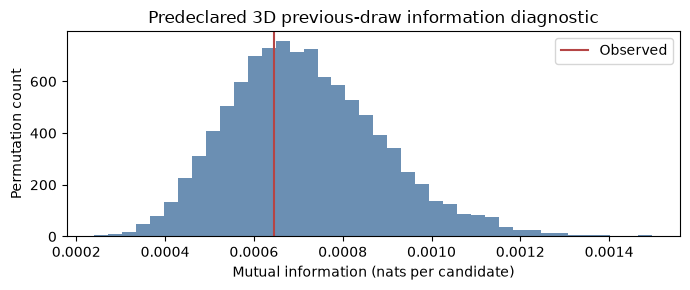

In [6]:
display(INFO.sort_values(['game', 'bh_q_within_game']))
family = 'previous_draw_appearance'
measure = 'multiplicity_count' if (INFO['game'] == '3d_lotto').any() else 'membership'
row = INFO[(INFO.game == '3d_lotto') & (INFO.diagnostic_family == family) & (INFO.target_measure == measure)].iloc[0]
null = PERM[(PERM.game == '3d_lotto') & (PERM.diagnostic_family == family) & (PERM.target_measure == measure)].mutual_information_nats_per_candidate
plt.figure(figsize=(7, 3))
plt.hist(null, bins=40, color='#6b8fb3')
plt.axvline(row.observed_mutual_information_nats_per_candidate, color='#b54545', label='Observed')
plt.title('Predeclared 3D previous-draw information diagnostic')
plt.xlabel('Mutual information (nats per candidate)'); plt.ylabel('Permutation count'); plt.legend(); plt.tight_layout(); plt.show()

## 7. Temporal-Dependence Analysis

**Analytical question:** Conditional rates with paired whole-draw intervals avoid treating candidate rows as independent.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** Use the previous-draw state plot and full CSV for all other predeclared state groups.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

,game,feature_group,state,training_draws,candidate_draw_cells,draws_with_state,conditional_presence_rate,unconditional_empirical_presence_rate,fair_marginal_presence_probability,rate_difference_from_empirical_baseline,paired_draw_bootstrap_delta_ci95_low,paired_draw_bootstrap_delta_ci95_high,conditional_mean_multiplicity,multiplicity_bootstrap_ci95_low,multiplicity_bootstrap_ci95_high,bootstrap_resamples,whole_draw_rows_resampled
0,3d_lotto,previous_draw_appearance,absent,2170,15856,2170,0.267659,0.269263,0.271000,-0.001604,-0.005425,0.002110,0.298814,0.294381,0.303221,10000,True
1,3d_lotto,previous_draw_appearance,present,2170,5844,2170,0.273614,0.269263,0.271000,0.004351,-0.005721,0.014728,0.303217,0.291245,0.315242,10000,True
2,3d_lotto,previous_10_frequency,quantile_bin_1,2170,2471,1673,0.264670,0.269263,0.271000,-0.004592,-0.021369,0.012181,0.289357,0.270046,0.308415,10000,True
3,3d_lotto,previous_10_frequency,quantile_bin_2,2170,4200,1954,0.269762,0.269263,0.271000,0.000499,-0.011218,0.012690,0.302619,0.288625,0.317039,10000,True
4,3d_lotto,previous_10_frequency,quantile_bin_3,2170,5612,2076,0.268354,0.269263,0.271000,-0.000909,-0.010902,0.009457,0.300071,0.288197,0.312124,10000,True
5,3d_lotto,previous_10_frequency,quantile_bin_4,2170,5726,2105,0.277506,0.269263,0.271000,0.008243,-0.001786,0.018252,0.308418,0.296607,0.319993,10000,True
6,3d_lotto,previous_10_frequency,quantile_bin_5,2170,3691,2017,0.260363,0.269263,0.271000,-0.008900,-0.022724,0.004664,0.290978,0.274642,0.307194,10000,True
7,3d_lotto,previous_30_frequency,quantile_bin_1,2170,3368,1957,0.268705,0.269263,0.271000,-0.000557,-0.014596,0.013563,0.298100,0.281490,0.314564,10000,True
8,3d_lotto,previous_30_frequency,quantile_bin_2,2170,3767,1887,0.260154,0.269263,0.271000,-0.009109,-0.022115,0.003981,0.294133,0.278592,0.310021,10000,True
9,3d_lotto,previous_30_frequency,quantile_bin_3,2170,4617,1970,0.269439,0.269263,0.271000,0.000176,-0.011223,0.011547,0.297163,0.283975,0.310329,10000,True


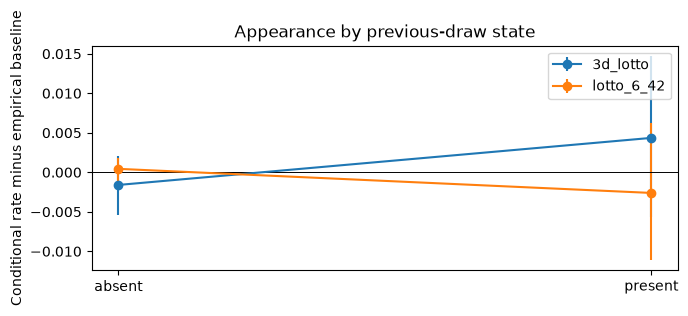

In [7]:
display(TEMP)
previous = TEMP[TEMP.feature_group == 'previous_draw_appearance'].copy()
if len(previous):
    plt.figure(figsize=(7, 3))
    for game, block in previous.groupby('game'):
        delta = block.rate_difference_from_empirical_baseline.to_numpy()
        low = block.paired_draw_bootstrap_delta_ci95_low.to_numpy()
        high = block.paired_draw_bootstrap_delta_ci95_high.to_numpy()
        plt.errorbar(block.state, delta, yerr=[(delta-low).clip(min=0), (high-delta).clip(min=0)], marker='o', label=game)
    plt.axhline(0, color='black', linewidth=.7)
    plt.ylabel('Conditional rate minus empirical baseline'); plt.title('Appearance by previous-draw state'); plt.legend(); plt.tight_layout(); plt.show()

## 8. Stationarity Diagnostics

**Analytical question:** Rolling entropy and marginal deviations show how the development history varies over time.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** Variation alone does not demonstrate a change in the physical draw process.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

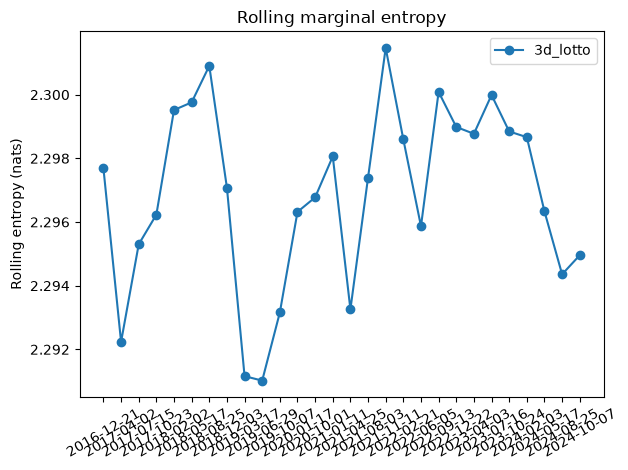

,game,start_date,end_date,value
0,3d_lotto,2016-04-16,2016-12-21,2.297688
7,3d_lotto,2016-07-25,2017-04-02,2.292235
14,3d_lotto,2016-11-02,2017-07-15,2.295299
21,3d_lotto,2017-02-12,2017-10-23,2.296231
28,3d_lotto,2017-05-27,2018-02-02,2.299518
35,3d_lotto,2017-09-04,2018-05-17,2.299758
42,3d_lotto,2017-12-13,2018-08-25,2.300904
49,3d_lotto,2018-03-25,2018-12-03,2.297077
56,3d_lotto,2018-07-07,2019-03-17,2.291159
63,3d_lotto,2018-10-15,2019-06-29,2.291019


In [8]:
rolling = STATION[STATION.diagnostic_type == 'rolling_window']
metric = 'marginal_digit_entropy_nats' if (rolling.game == '3d_lotto').any() else 'marginal_number_entropy_nats'
block = rolling[rolling.metric == metric]
for game, values in block.groupby('game'):
    plt.plot(values.end_date, values.value, marker='o', label=game)
plt.xticks(rotation=30); plt.ylabel('Rolling entropy (nats)'); plt.title('Rolling marginal entropy'); plt.legend(); plt.tight_layout(); plt.show()
display(block[['game', 'start_date', 'end_date', 'value']])

## 9. Change-Point Investigation

**Analytical question:** A bounded max-shift scan corrects for searching candidate cuts and uses complete-draw row permutations.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** Any flagged date is a statistical screen, not an explanation.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

In [9]:
change = STATION[STATION.diagnostic_type == 'bounded_change_point']
display(change[['game', 'metric', 'estimated_cut_after_date', 'value', 'p_value', 'bh_q_within_change_family']])

,game,metric,estimated_cut_after_date,value,p_value,bh_q_within_change_family
202,3d_lotto,draw_sum,2021-08-28,1.485772,0.788321,0.941906
203,3d_lotto,all_distinct_indicator,2024-01-09,1.830795,0.537546,0.941906
204,3d_lotto,triple_indicator,2017-01-17,1.448684,0.828817,0.941906
205,3d_lotto,previous_draw_overlap,2022-03-18,1.205425,0.941906,0.941906
267,lotto_6_42,draw_sum,2018-02-08,2.434913,0.118588,0.249575
268,lotto_6_42,odd_count,2019-02-02,2.050487,0.259374,0.259374
269,lotto_6_42,previous_draw_overlap,2019-09-28,2.295025,0.166383,0.249575


## 10. Bayesian Shrinkage Framework

**Analytical question:** Dirichlet and Beta priors pull weak marginal estimates toward the fair reference.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** Prior strength sensitivity is reported; it was not selected on validation performance.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

,game,model,mean_posterior,mean_raw,mean_abs_change
0,3d_lotto,dirichlet_kappa_10,0.100000,0.100000,0.000003
1,3d_lotto,dirichlet_kappa_100,0.100000,0.100000,0.000035
2,3d_lotto,dirichlet_kappa_1000,0.100000,0.100000,0.000310
3,3d_lotto,raw_expanding_frequency,0.100000,0.100000,0.000000
4,lotto_6_42,beta_kappa_10,0.142857,0.142857,0.000063
5,lotto_6_42,beta_kappa_100,0.142857,0.142857,0.000588
6,lotto_6_42,beta_kappa_1000,0.142857,0.142857,0.003404
7,lotto_6_42,raw_expanding_frequency,0.142857,0.142857,0.000000


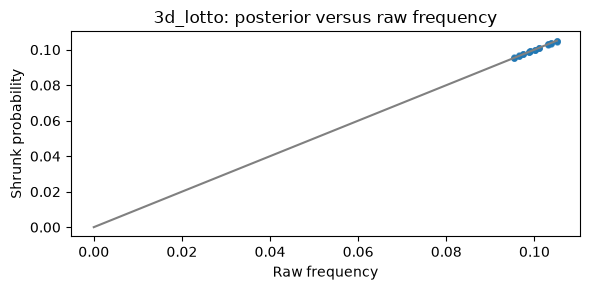

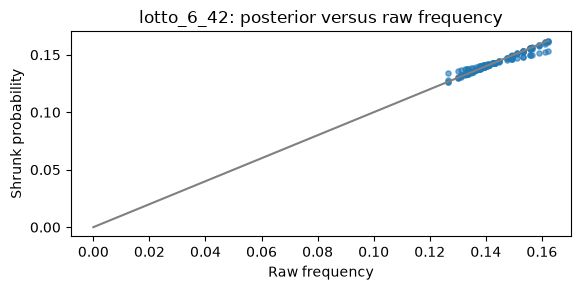

In [10]:
display(BAYES.groupby(['game', 'model']).agg(mean_posterior=('posterior_probability', 'mean'), mean_raw=('raw_historical_frequency', 'mean'), mean_abs_change=('difference_from_raw_frequency', lambda x: x.abs().mean())).reset_index())
means = BAYES.groupby(['game', 'model', 'candidate'])[['posterior_probability', 'raw_historical_frequency']].mean().reset_index()
for game, block in means.groupby('game'):
    plt.figure(figsize=(6, 3)); plt.scatter(block.raw_historical_frequency, block.posterior_probability, s=14, alpha=.6); plt.plot([0, block[['raw_historical_frequency','posterior_probability']].to_numpy().max()], [0, block[['raw_historical_frequency','posterior_probability']].to_numpy().max()], color='gray'); plt.title(f'{game}: posterior versus raw frequency'); plt.xlabel('Raw frequency'); plt.ylabel('Shrunk probability'); plt.tight_layout(); plt.show()

## 11. 3D Conditional Digit Probabilities

**Analytical question:** The posterior digit vectors are the inputs to a valid unordered-multiset model.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** A marginal digit probability is not itself a multiset probability.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

In [11]:
display(BAYES[BAYES.game == '3d_lotto'].groupby(['model', 'candidate']).posterior_probability.mean().unstack('model').head(10))

model,dirichlet_kappa_10,dirichlet_kappa_100,dirichlet_kappa_1000,raw_expanding_frequency
candidate,,,,
0,0.105081,0.105023,0.104513,0.105087
1,0.103853,0.103809,0.103418,0.103858
2,0.098720,0.098735,0.098866,0.098719
3,0.096468,0.096508,0.096863,0.096464
4,0.098989,0.099001,0.099106,0.098988
5,0.100934,0.100923,0.100829,0.100935
6,0.100040,0.100038,0.100025,0.100040
7,0.103175,0.103140,0.102824,0.103179
8,0.097448,0.097477,0.097734,0.097445


## 12. 3D 220-Multiset Probability Distribution

**Analytical question:** The multinomial multiplicity coefficient yields an exact distribution over all valid multisets.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** Every validation forecast's full 220-outcome distribution was checked to sum to one.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

,model,max_normalization_error,mean_nll,mean_rank
0,dirichlet_kappa_10,5.551115e-16,5.321316,88.983402
1,dirichlet_kappa_100,7.771561e-16,5.321281,88.982019
2,dirichlet_kappa_1000,7.771561e-16,5.320988,88.986169
3,fair_random,0.000000e+00,5.319894,88.583679
4,raw_expanding_frequency,7.771561e-16,5.321320,88.986169


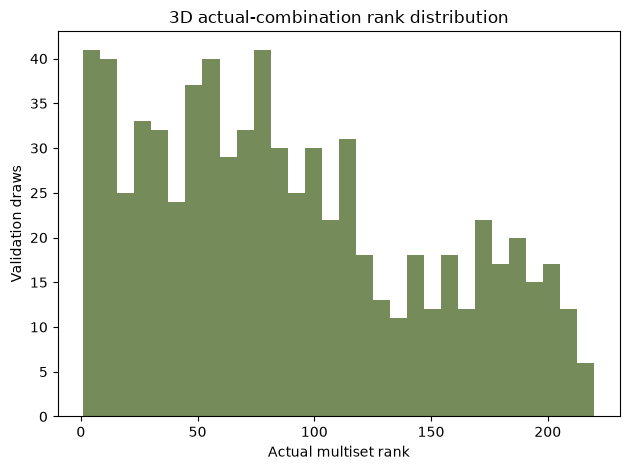

In [12]:
display(METRICS[METRICS.game == '3d_lotto'].groupby('model').agg(max_normalization_error=('probability_sum_over_all_valid_outcomes', lambda s: (s - 1).abs().max()), mean_nll=('actual_combination_nll_nats', 'mean'), mean_rank=('actual_combination_rank', 'mean')).reset_index())
ranked = METRICS[(METRICS.game == '3d_lotto') & METRICS.actual_combination_rank.notna()]
plt.hist(ranked[ranked.model == 'dirichlet_kappa_100'].actual_combination_rank, bins=30, color='#758b5a'); plt.xlabel('Actual multiset rank'); plt.ylabel('Validation draws'); plt.title('3D actual-combination rank distribution'); plt.tight_layout(); plt.show()

## 13. 3D Combination-Level Validation

**Analytical question:** Ranks and proper combination log scores compare full outcomes chronologically.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** Top-k rates are secondary and cannot establish useful predictive power alone.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

In [13]:
display(METRICS[METRICS.game == '3d_lotto'].groupby('model').agg(mean_nll=('actual_combination_nll_nats', 'mean'), mean_log_advantage=('log_score_advantage_vs_fair', 'mean'), top5=('top_5_inclusion', 'mean')).reset_index())

,model,mean_nll,mean_log_advantage,top5
0,dirichlet_kappa_10,5.321316,-0.001423,0.030429
1,dirichlet_kappa_100,5.321281,-0.001387,0.030429
2,dirichlet_kappa_1000,5.320988,-0.001094,0.030429
3,fair_random,5.319894,0.000000,0.031812
4,raw_expanding_frequency,5.321320,-0.001427,0.030429


## 14. Lotto 6/42 Candidate Weights

**Analytical question:** Positive odds weights preserve the fixed-cardinality model's support.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** Marginal Beta posteriors are candidates for weights, not independent Bernoulli draw probabilities.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

In [14]:
display(BAYES[BAYES.game == 'lotto_6_42'].groupby('model').agg(mean_posterior=('posterior_probability', 'mean'), mean_raw=('raw_historical_frequency', 'mean'), min_weight=('candidate_weight', 'min')).reset_index())

,model,mean_posterior,mean_raw,min_weight
0,beta_kappa_10,0.142857,0.142857,0.138905
1,beta_kappa_100,0.142857,0.142857,0.140899
2,beta_kappa_1000,0.142857,0.142857,0.151672
3,raw_expanding_frequency,0.142857,0.142857,0.138664


## 15. Fixed-Cardinality 6/42 Combination Model

**Analytical question:** The sixth elementary symmetric polynomial exactly normalizes the product-weight distribution.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** A small independent enumeration validates the DP; no millions-of-sets loop is used per draw.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

In [15]:
print(EVIDENCE['fair_random_verification']['642']['synthetic_dp_normalizer'], EVIDENCE['fair_random_verification']['642']['synthetic_enumerated_normalizer'])
display(METRICS[METRICS.game == 'lotto_6_42'].groupby('model').agg(mean_nll=('actual_combination_nll_nats', 'mean'), max_marginal_sum_error=('marginal_inclusion_sum', lambda s: (s - 6).abs().max())).reset_index())

27.06875 27.06875


,model,mean_nll,max_marginal_sum_error
0,beta_kappa_10,15.497611,2.664535e-15
1,beta_kappa_100,15.494869,3.552714e-15
2,beta_kappa_1000,15.482702,2.664535e-15
3,fair_random,15.472936,0.000000e+00
4,raw_expanding_frequency,15.497953,2.664535e-15


## 16. Lotto 6/42 Combination-Level Validation

**Analytical question:** Complete-set NLL, marginal Brier, and hits@6 describe different aspects of the same forecast.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** Hits@6 is secondary to the exact complete-set probability score.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

In [16]:
display(METRICS[METRICS.game == 'lotto_6_42'].groupby('model').agg(mean_nll=('actual_combination_nll_nats', 'mean'), mean_log_advantage=('log_score_advantage_vs_fair', 'mean'), mean_hits_at_6=('hits_at_6', 'mean'), marginal_brier=('marginal_brier', 'mean')).reset_index())

,model,mean_nll,mean_log_advantage,mean_hits_at_6,marginal_brier
0,beta_kappa_10,15.497611,-2.467567e-02,0.90,0.122594
1,beta_kappa_100,15.494869,-2.193334e-02,0.90,0.122578
2,beta_kappa_1000,15.482702,-9.766793e-03,0.90,0.122507
3,fair_random,15.472936,1.776357e-15,0.84,0.122449
4,raw_expanding_frequency,15.497953,-2.501744e-02,0.90,0.122596


## 17. Proper-Scoring-Rule Comparison

**Analytical question:** Bootstrap intervals and fair-null simulations compare log scores while preserving complete validation rows.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** The Monte Carlo comparison conditions on the observed forecast path and is not pristine confirmation.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

,game,model,mean_log_score_advantage_vs_fair,bootstrap_ci95,mc_p
0,3d_lotto,dirichlet_kappa_10,-0.001423,"[-0.005345350641773413, 0.0025205463775063346]",0.485551
1,3d_lotto,dirichlet_kappa_100,-0.001387,"[-0.005264414486922492, 0.002511420645470164]",0.484852
2,3d_lotto,dirichlet_kappa_1000,-0.001094,"[-0.00456699802518088, 0.0024106831461200777]",0.481352
3,3d_lotto,fair_random,0.000000,"[0.0, 0.0]",NaN
4,3d_lotto,raw_expanding_frequency,-0.001427,"[-0.005354484300375572, 0.0025215451918323716]",0.485551
5,lotto_6_42,beta_kappa_10,-0.024676,"[-0.04369262348565588, -0.006011895490789998]",0.866913
6,lotto_6_42,beta_kappa_100,-0.021933,"[-0.03957462250534383, -0.004591364595839638]",0.865813
7,lotto_6_42,beta_kappa_1000,-0.009767,"[-0.020024254970673967, 0.0003265359030290533]",0.862014
8,lotto_6_42,fair_random,0.000000,"[0.0, 0.0]",NaN
9,lotto_6_42,raw_expanding_frequency,-0.025017,"[-0.044212729007720546, -0.006185513739841158]",0.867013


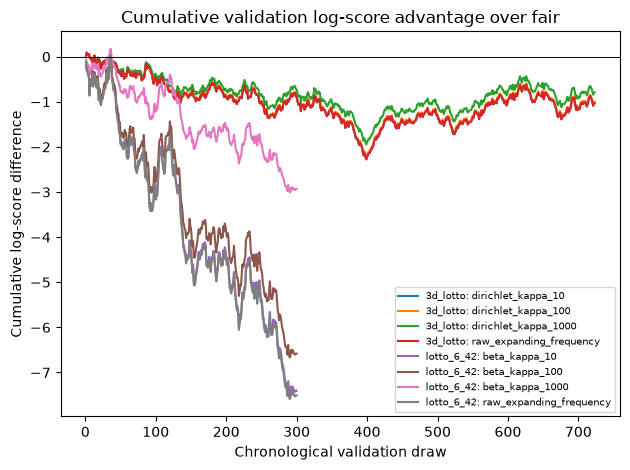

In [17]:
rows = []
for game, models in EVIDENCE['combination_validation'].items():
    for model, stats in models['models'].items():
        rows.append({'game': game, 'model': model, 'mean_log_score_advantage_vs_fair': stats['mean_log_score_advantage_vs_fair'], 'bootstrap_ci95': EVIDENCE['bootstrap'][game][model]['bootstrap_ci95_vs_fair'], 'mc_p': EVIDENCE['fair_random_monte_carlo'][game].get('models', {}).get(model, {}).get('empirical_p_add_one')})
display(pd.DataFrame(rows))
for game, group in METRICS.groupby('game'):
    for model, sub in group.groupby('model'):
        if model == 'fair_random': continue
        sub = sub.sort_values(['draw_date', 'source_row'])
        plt.plot(range(1, len(sub)+1), sub.log_score_advantage_vs_fair.cumsum(), label=f'{game}: {model}')
plt.axhline(0, color='black', linewidth=.7); plt.title('Cumulative validation log-score advantage over fair'); plt.xlabel('Chronological validation draw'); plt.ylabel('Cumulative log-score difference'); plt.legend(fontsize=7); plt.tight_layout(); plt.show()

## 18. Predictive Information Evidence Summary

**Analytical question:** The gate requires corrected information, proper-score improvement, chronological stability, and calibration evidence.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** No individual p-value can bypass the combined evidence gate.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

In [18]:
display(pd.DataFrame([EVIDENCE['decision_evidence']]))
print('Information diagnostics with BH q < .05:', int((INFO.bh_q_within_game < .05).sum()))

,bh_adjusted_information_detected,chronological_direction_stability_detected,conditional_monte_carlo_p_gate_detected,decision_gate,marginal_calibration_screen_passed_by_any_candidate,proper_score_bootstrap_improvement_vs_fair_and_raw_detected,qualifying_models
0,True,False,False,BH q < 0.05 plus paired 95% bootstrap interval...,True,False,[]


Information diagnostics with BH q < .05: 1


## 19. Limitations and Unsupported Theories

**Analytical question:** Physical, quantum, and game-theoretic models require variables absent from these data.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** No unsupported model branch or draw recommendation is included.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

In [19]:
print('No physical machine-state variables, quantum observables, player-choice data, or payout-sharing data were used.')
print(EVIDENCE['limitations'])

No physical machine-state variables, quantum observables, player-choice data, or payout-sharing data were used.
['Phase 5A already examined the validation partitions; Phase 5R validation is development evidence, not pristine confirmation.', 'The Monte Carlo fair-null test holds the observed leakage-safe forecast path fixed and simulates complete fair validation outcomes conditionally.', 'The information tests are finite-sample candidate-level diagnostics on the training sequence and do not imply full-combination utility.', 'Stationarity and change-point tests can detect statistical variation but cannot identify a machine, ball, environmental, or physical cause.', 'Physical dynamics require machine state, ball properties, airflow, timing, temperature, humidity, or video trajectory data.', 'Quantum methods are not predictors supported by the available variables; player-choice and payout-sharing data are absent for game-theoretic expected-payout analysis.', 'No probability calibration acc

## 20. Final Phase 5R Decision

**Analytical question:** The verdict follows the recorded evidence gate and preserves the future test boundary.

**Why this method fits:** The analysis uses only Phase 4 train and validation prefixes and respects each game's complete-draw outcome structure.

**Interpretation:** A later one-time test requires a separately authorized phase and a frozen model.

**Limitation:** Validation has already been examined in Phase 5A and is development evidence. Locked test targets are not read.

In [20]:
print('Verdict:', EVIDENCE['verdict'])
print('Safest next action:', EVIDENCE['safest_next_action'])

Verdict: PHASE5R_INCONCLUSIVE
Safest next action: Stop model expansion and keep the locked test untouched. The current evidence does not justify freezing a Phase 5R candidate for the one-time test evaluation; use any future confirmation only in a separately authorized phase after an explicit model freeze.
